# Regressão Logística — do Intuitivo ao Prático

Bem-vindo(a)! Este notebook foi organizado para ensinar **Regressão Logística** de forma **progressiva e visual**.

**Você vai ver:**
1. Motivação e quando usar
2. Fundamentos matemáticos (sigmóide, fronteira de decisão)
3. Visualizações (reta vs sigmóide, 2D e 1D)
4. Treinando o modelo
5. Matriz de confusão (VN, FP, FN, VP)
6. Precisão, Recall e **F1-score**
7. **Curva ROC** e **AUC**
8. **Curva Precisão–Recall**
9. Caso prático - *Titanic* 

## 1) Motivação
A regressão logística é usada quando o alvo é **binário** (0/1):
- Spam vs. não-spam
- Aprova vs. reprova
- Sobrevive vs. não sobrevive

Por que não usar regressão linear? Porque ela pode prever valores fora de [0,1] e não é uma probabilidade.


## 2) Fundamentos
1. Combinamos linearmente as variáveis:
$$ z = \beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n $$
2. Passamos por uma **sigmóide**:
$$ \sigma(z) = \frac{1}{1+e^{-z}} $$
3. Interpretamos como **probabilidade** $P(y=1\mid x)$.

A **fronteira de decisão** para limiar 0.5 acontece quando $\sigma(z)=0.5 \Rightarrow z=0$.


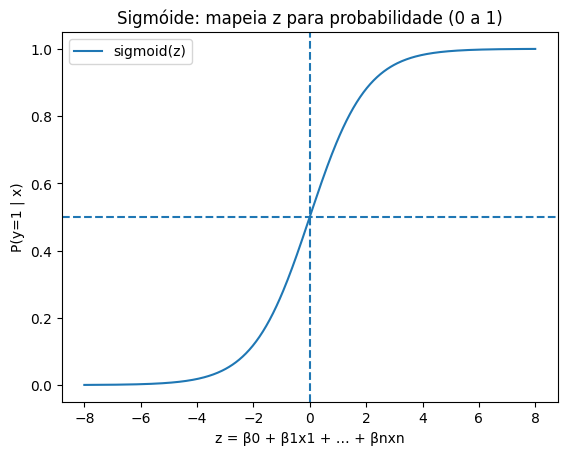

In [1]:
# 3) Visual: Curva sigmóide
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-8, 8, 400)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure()
plt.plot(z, sigmoid, label="sigmoid(z)")
plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")
plt.title("Sigmóide: mapeia z para probabilidade (0 a 1)")
plt.xlabel("z = β0 + β1x1 + … + βnxn")
plt.ylabel("P(y=1 | x)")
plt.legend()
plt.show()

## 3) Visualizações Intuitivas
### 3.1) Fronteira de decisão em 2D
Em duas variáveis, a fronteira é uma **reta** (quando o modelo é linear).

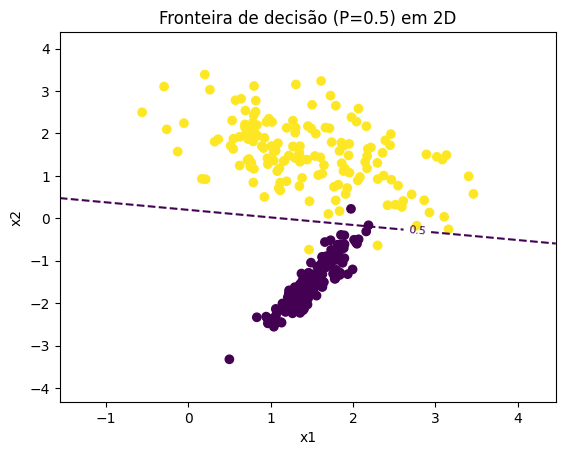

In [2]:
# Fronteira de decisão em 2D (probabilidade = 0.5)
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

X2, y2 = make_classification(
    n_samples=300, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)

clf2 = LogisticRegression()
clf2.fit(X2, y2)

x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
proba = clf2.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure()
cs = plt.contour(xx, yy, proba, levels=[0.5], linestyles="--")
plt.scatter(X2[:, 0], X2[:, 1], c=y2)
plt.clabel(cs, inline=True, fontsize=8)
plt.title("Fronteira de decisão (P=0.5) em 2D")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

### 3.2) Linear vs Logística em 1D
Aqui fica **nítido**: a linear gera uma **reta** e pode passar de [0,1], enquanto a logística produz uma **sigmóide**.


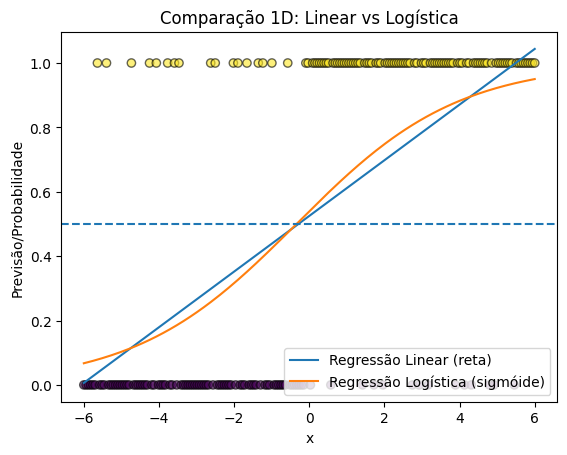

In [3]:
from sklearn.linear_model import LinearRegression
np.random.seed(42)
X1 = np.linspace(-6, 6, 200).reshape(-1, 1)
y1 = (X1[:,0] > 0).astype(int)
# ruído (15%): espalha alguns pontos
flip_mask = np.random.rand(len(y1)) < 0.15
y1_noisy = y1.copy()
y1_noisy[flip_mask] = 1 - y1_noisy[flip_mask]

linreg = LinearRegression().fit(X1, y1_noisy)
logreg = LogisticRegression().fit(X1, y1_noisy)

yhat_lin = linreg.predict(X1)
yhat_log = logreg.predict_proba(X1)[:,1]

plt.figure()
plt.scatter(X1, y1_noisy, c=y1_noisy, edgecolor="k", alpha=0.6)
plt.plot(X1, yhat_lin, label="Regressão Linear (reta)")
plt.plot(X1, yhat_log, label="Regressão Logística (sigmóide)")
plt.axhline(0.5, linestyle="--")
plt.title("Comparação 1D: Linear vs Logística")
plt.xlabel("x"); plt.ylabel("Previsão/Probabilidade")
plt.legend(); plt.show()

### Comparação 1D: Linear vs Logística

A imagem mostra a diferença entre **Regressão Linear** e **Regressão Logística** para um problema de classificação binária em uma dimensão.

- **Pontos:** Cada ponto representa uma amostra, com valores 0 ou 1 (classes).
- **Linha azul (reta):** É a previsão da Regressão Linear. Ela pode assumir valores fora do intervalo [0, 1], o que não faz sentido para probabilidades.
- **Linha laranja (sigmóide):** É a previsão da Regressão Logística. Ela sempre fica entre 0 e 1, pois usa a função sigmóide para mapear a saída para probabilidades.
- **Linha tracejada:** Marca o limiar de decisão em 0.5, típico para separar as classes.

**Resumo:**  
A Regressão Logística é mais adequada para classificação binária porque retorna probabilidades e define uma fronteira de decisão clara, enquanto a Regressão Linear não é limitada ao intervalo [0, 1] e pode gerar previsões incoerentes para esse tipo de problema.

## 4) Treinando o modelo
Nesta seção, treinaremos rapidamente um modelo em dados simples para fixar a ideia.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.3, random_state=7, stratify=y2)
clf_simple = LogisticRegression()
clf_simple.fit(X_train, y_train)
print("Acurácia (simples, 2D):", clf_simple.score(X_test, y_test))

Acurácia (simples, 2D): 0.9555555555555556


## 5) Matriz de Confusão
A matriz organiza os acertos/erros:
- **VN**: 0 previsto e 0 real
- **FP**: 1 previsto, 0 real
- **FN**: 0 previsto, 1 real
- **VP**: 1 previsto, 1 real


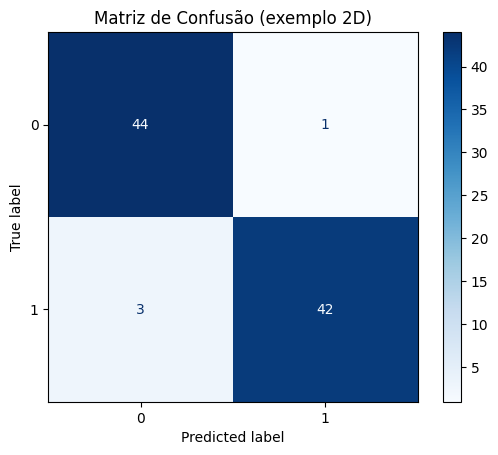

{'VN': 44, 'FP': 1, 'FN': 3, 'VP': 42}


In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_simple = clf_simple.predict(X_test)
cm = confusion_matrix(y_test, y_pred_simple)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão (exemplo 2D)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print({"VN":int(tn), "FP":int(fp), "FN":int(fn), "VP":int(tp)})

### Análise da Matriz de Confusão (exemplo 2D)

A matriz de confusão mostra o desempenho do modelo de classificação em termos de acertos e erros para cada classe:

- **Diagonal principal (44 e 42):**  
  - **44:** Casos em que o modelo previu 0 e o verdadeiro também era 0 (**Verdadeiros Negativos — VN**).
  - **42:** Casos em que o modelo previu 1 e o verdadeiro também era 1 (**Verdadeiros Positivos — VP**).

- **Fora da diagonal (1 e 3):**  
  - **1:** Casos em que o modelo previu 1, mas o verdadeiro era 0 (**Falsos Positivos — FP**).
  - **3:** Casos em que o modelo previu 0, mas o verdadeiro era 1 (**Falsos Negativos — FN**).

**Resumo:**  
O modelo acertou a maioria dos casos, errando poucos exemplos (apenas 1 FP e 3 FN). Isso indica um bom desempenho, com alta taxa de acerto tanto para a classe 0 quanto para a classe 1.

## 6) Precisão, Recall e F1

- **Precisão (Precision):** Mede a proporção de exemplos classificados como positivos que realmente são positivos.  
  $$ \text{Precisão} = \frac{VP}{VP + FP} $$
  Onde VP = Verdadeiros Positivos e FP = Falsos Positivos.

- **Recall (Sensibilidade):** Mede a proporção de exemplos positivos que foram corretamente identificados pelo modelo.  
  $$ \text{Recall} = \frac{VP}{VP + FN} $$
  Onde FN = Falsos Negativos.

- **F1-score:** É a média harmônica entre Precisão e Recall, fornecendo uma medida única que equilibra ambos.  
  $$ F1 = 2 \cdot \frac{\text{Precisão} \cdot \text{Recall}}{\text{Precisão} + \text{Recall}} $$

**Resumo:**  
- Use **Precisão** quando o custo de um falso positivo é alto.  
- Use **Recall** quando o custo de um falso negativo é alto.  
- O **F1-score** é útil quando há necessidade de equilíbrio entre Precisão e Recall, especialmente em conjuntos de dados desbalanceados.


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
acc = accuracy_score(y_test, y_pred_simple)
prec = precision_score(y_test, y_pred_simple)
rec = recall_score(y_test, y_pred_simple)
f1 = f1_score(y_test, y_pred_simple)
print(f"Acurácia: {acc:.3f} | Precisão: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")

Acurácia: 0.956 | Precisão: 0.977 | Recall: 0.933 | F1: 0.955


## 7) Curva ROC e AUC
- **ROC** plota **TPR (Recall)** vs **FPR** em vários limiares.
- **AUC** é a área sob a curva: 0.5 é aleatório; quanto mais perto de 1, melhor.

### Curva ROC e AUC

- **Curva ROC (Receiver Operating Characteristic):**  
  A curva ROC mostra a relação entre a taxa de verdadeiros positivos (**TPR** ou **Recall**) e a taxa de falsos positivos (**FPR**) para diferentes limiares de decisão do modelo.  
  - **TPR (True Positive Rate):** Proporção de positivos corretamente identificados.
  - **FPR (False Positive Rate):** Proporção de negativos incorretamente classificados como positivos.

- **Como interpretar:**  
  Cada ponto da curva representa um limiar diferente. Uma curva mais próxima do canto superior esquerdo indica melhor desempenho, pois o modelo consegue alto recall com baixo FPR.

- **AUC (Area Under the Curve):**  
  É a área sob a curva ROC. Mede a capacidade do modelo de separar as classes:
  - **AUC = 0.5:** Modelo aleatório (sem poder de discriminação).
  - **AUC = 1.0:** Modelo perfeito.
  - **Quanto maior o AUC, melhor o modelo.**

**Resumo:**  
A curva ROC e o AUC são métricas importantes para avaliar modelos de classificação, especialmente quando as classes estão desbalanceadas ou quando é importante analisar o desempenho em diferentes limiares de decisão.

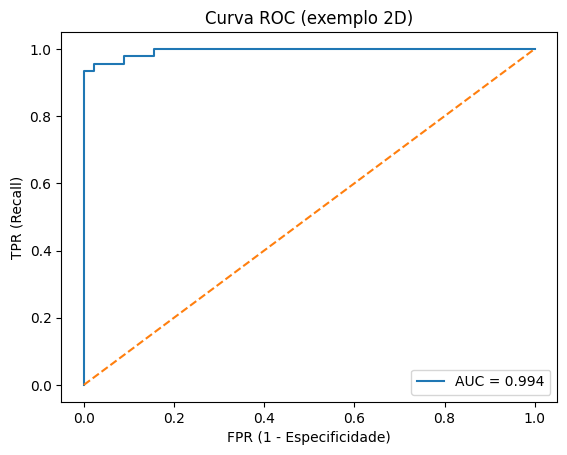

In [6]:
from sklearn.metrics import roc_curve, auc
y_proba_simple = clf_simple.predict_proba(X_test)[:,1]
fpr, tpr, thr = roc_curve(y_test, y_proba_simple)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR (1 - Especificidade)")
plt.ylabel("TPR (Recall)")
plt.title("Curva ROC (exemplo 2D)")
plt.legend(); plt.show()

## 8) Curva Precisão–Recall
Útil em **classes desbalanceadas**. Mostra o trade-off entre **Precisão** e **Recall**.


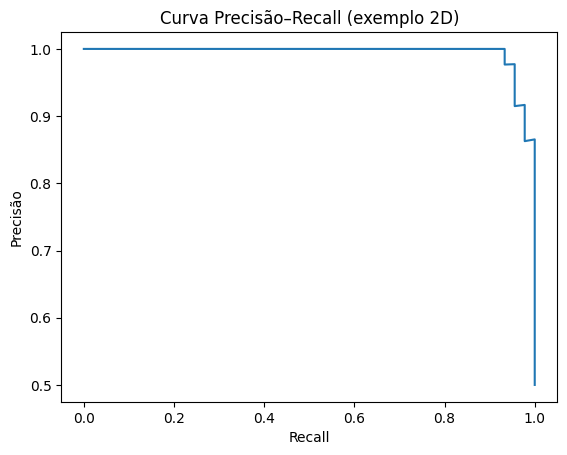

In [7]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thr_pr = precision_recall_curve(y_test, y_proba_simple)
plt.figure()
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precisão–Recall (exemplo 2D)")
plt.show()

## 9) Caso prático *Titanic*

A base de dados Titanic é um dos conjuntos de dados mais famosos para problemas de classificação. Ela contém informações sobre os passageiros do navio Titanic, que afundou em 1912, e o objetivo é prever quem `sobreviveu ao desastre`.

Cada linha representa um passageiro e inclui diversas variáveis, como:

- **survived**: Indica se o passageiro sobreviveu (1) ou não (0).  
- **pclass**: Classe do bilhete do passageiro (1ª, 2ª ou 3ª classe).  
- **sex**: Sexo do passageiro (`male` = masculino, `female` = feminino).  
- **age**: Idade do passageiro em anos.  
- **sibsp**: Número de irmãos/irmãs e cônjuges a bordo.  
- **parch**: Número de pais/mães e filhos a bordo.  
- **fare**: Tarifa paga pelo bilhete.  
- **embarked**: Porto de embarque (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton).  
- **class**: Classe do bilhete em formato textual (`First`, `Second`, `Third`).  
- **who**: Identificação do passageiro como `man`, `woman` ou `child`.  
- **adult_male**: Indica se o passageiro é um homem adulto (`True` ou `False`).  
- **deck**: Letra correspondente ao convés da cabine (pode ser `NaN` se desconhecido).  
- **embark_town**: Cidade correspondente ao porto de embarque (`Cherbourg`, `Queenstown`, `Southampton`).  
- **alive**: Indica se o passageiro sobreviveu (`yes`) ou não (`no`).  
- **alone**: Indica se o passageiro estava sozinho a bordo (`True`) ou acompanhado (`False`).  

Essas informações permitem analisar fatores que influenciaram a sobrevivência dos passageiros e são amplamente utilizadas para treinar e avaliar modelos de classificação, como a Regressão Logística.

### Carregar dataset

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# Carregar o dataset Titanic diretamente do seaborn
df = sns.load_dataset('titanic')

# Visualizar as primeiras linhas
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
df.shape

(891, 15)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [12]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Análise Exploratória

#### Gráfico 1 — Taxa de sobrevivência por sexo

Uma das primeiras análises exploratórias é verificar se houve diferença na taxa de sobrevivência entre homens e mulheres.  
Esse gráfico mostra a proporção de passageiros que sobreviveram (`survived = 1`) e que não sobreviveram (`survived = 0`), separados por sexo (`male`, `female`).  

**O que observar:**  
- A diferença clara entre homens e mulheres.  
- Proporções relativas dentro de cada grupo (homens e mulheres).  
- Esse padrão pode ser explicado pela prioridade dada a mulheres e crianças durante o resgate.  

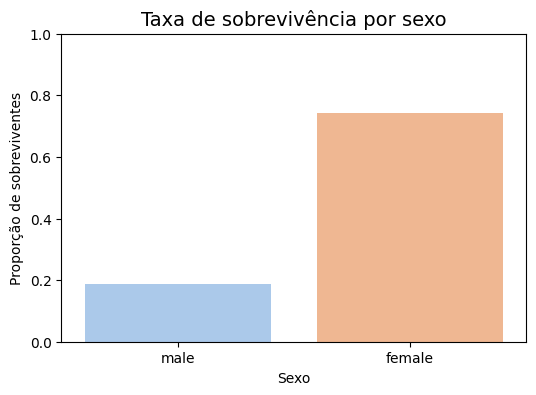

In [14]:
# Gráfico de barras com proporções de sobrevivência por sexo
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="sex",
    y="survived",
    hue="sex",       # usamos 'sex' como hue
    legend=False,    # removemos a legenda redundante
    estimator=lambda x: sum(x)/len(x), # proporção média
    errorbar=None,
    palette="pastel"
)

plt.title("Taxa de sobrevivência por sexo", fontsize=14)
plt.ylabel("Proporção de sobreviventes")
plt.xlabel("Sexo")
plt.ylim(0,1)
plt.show()

#### Gráfico 2 — Taxa de sobrevivência por classe do bilhete

Outro fator importante para analisar é a **classe do bilhete** do passageiro (`pclass`), que indica 1ª, 2ª ou 3ª classe.  
Esse gráfico mostra a proporção de sobreviventes em cada classe.  

**O que observar:**  
- Passageiros da 1ª classe tiveram maior taxa de sobrevivência.  
- A 3ª classe apresenta a menor taxa.  
- Isso reflete aspectos socioeconômicos e de acesso aos recursos de resgate.

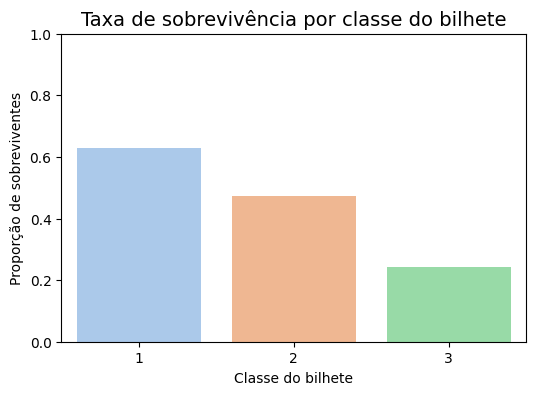

In [15]:
# Gráfico de barras com proporções de sobrevivência por classe
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="pclass",       # usa pclass como hue para evitar warning
    legend=False,
    estimator=lambda x: sum(x)/len(x), # proporção
    errorbar=None,
    palette="pastel"
)

plt.title("Taxa de sobrevivência por classe do bilhete", fontsize=14)
plt.ylabel("Proporção de sobreviventes")
plt.xlabel("Classe do bilhete")
plt.ylim(0,1)
plt.show()

#### Gráfico 3 — Distribuição de idade por status de sobrevivência

Este gráfico compara a **distribuição de idades** entre quem **não sobreviveu (0)** e quem **sobreviveu (1)**.

**O que observar:**
- Diferenças nas **medianas** e **dispersões** entre os grupos.
- Presença de **crianças** no grupo que sobreviveu (políticas de “mulheres e crianças primeiro”).
- Possíveis **outliers** (idades muito altas).
- **Atenção**: há valores ausentes em `age`; aqui estamos **removendo NaN** apenas para o gráfico (sem afetar o dataset original).

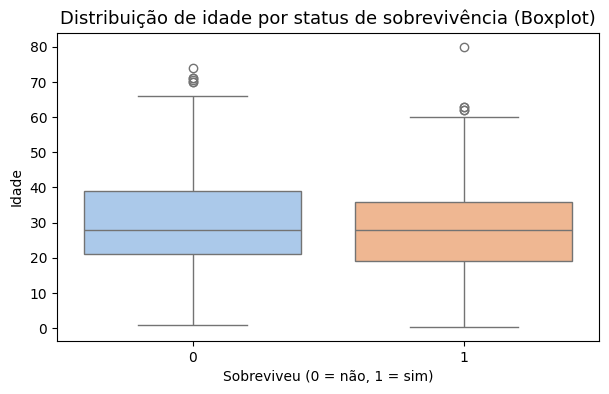

In [16]:
# Filtra apenas linhas com idade conhecida
df_age = df.dropna(subset=["age"]).copy()

plt.figure(figsize=(7,4))
sns.boxplot(
    data=df_age,
    x="survived",
    y="age",
    hue="survived",    # evita warning do seaborn
    legend=False,
    palette="pastel"
)
plt.title("Distribuição de idade por status de sobrevivência (Boxplot)", fontsize=13)
plt.xlabel("Sobreviveu (0 = não, 1 = sim)")
plt.ylabel("Idade")
plt.show()

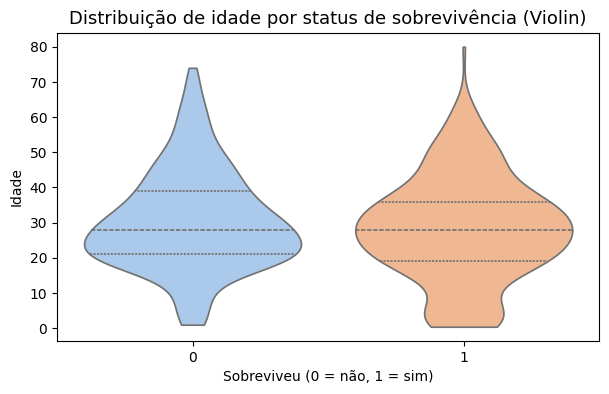

In [17]:
plt.figure(figsize=(7,4))
sns.violinplot(
    data=df_age,
    x="survived",
    y="age",
    hue="survived",    # evita warning do seaborn
    legend=False,
    inner="quartile",  # mostra mediana e quartis
    cut=0,
    palette="pastel"
)
plt.title("Distribuição de idade por status de sobrevivência (Violin)", fontsize=13)
plt.xlabel("Sobreviveu (0 = não, 1 = sim)")
plt.ylabel("Idade")
plt.show()

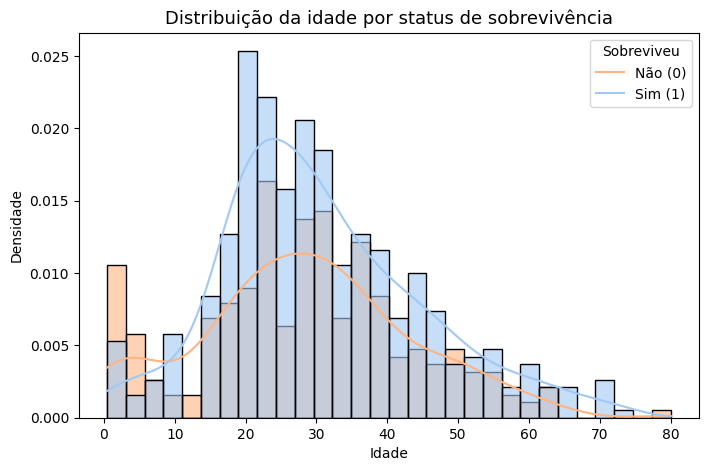

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df_age,
    x="age",
    hue="survived",
    kde=True,         # adiciona curva de densidade
    stat="density",   # normaliza para facilitar comparação
    bins=30,
    palette="pastel",
    alpha=0.6
)
plt.title("Distribuição da idade por status de sobrevivência", fontsize=13)
plt.xlabel("Idade")
plt.ylabel("Densidade")
plt.legend(title="Sobreviveu", labels=["Não (0)", "Sim (1)"])
plt.show()

#### Interpretação do histograma (idade × sobrevivência)

- O histograma foi dividido em 30 intervalos (bins).  
- Como a idade vai de 0 a 80 anos, cada barra cobre cerca de 2,67 anos.  
- A primeira barra corresponde à faixa de **0 a ~2,7 anos** (bebês e crianças pequenas).  

Se a altura dessa barra é **0.010** no eixo de densidade:  
- Multiplicamos pela largura do intervalo (2,67).  
- Isso significa que **cerca de 2,7% dos passageiros** do grupo analisado estão nessa faixa de idade.

#### Gráfico 4 — Distribuição de sobreviventes vs não sobreviventes

Antes de ajustar qualquer modelo de classificação, é fundamental observar se as classes estão **equilibradas** ou não.  
Esse gráfico mostra a **quantidade de passageiros sobreviventes (1)** e **não sobreviventes (0)** no dataset Titanic.  

**O que observar:**  
- Se uma classe é muito mais frequente que a outra, o modelo pode tender a “chutar sempre a maioria”.  
- No Titanic, há mais passageiros que **não sobreviveram** do que passageiros que **sobreviveram** → um certo desbalanceamento.

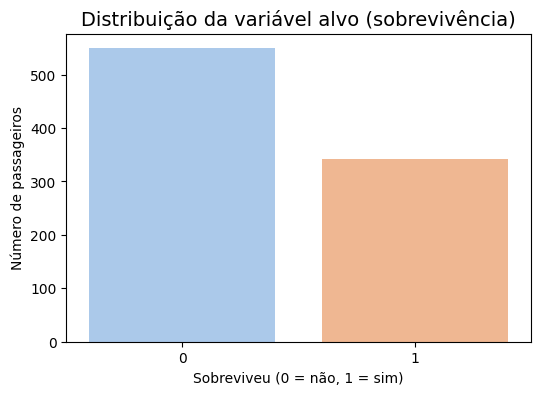

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="survived",
    hue="survived",
    legend=False,
    palette="pastel"
)

plt.title("Distribuição da variável alvo (sobrevivência)", fontsize=14)
plt.xlabel("Sobreviveu (0 = não, 1 = sim)")
plt.ylabel("Número de passageiros")
plt.show()

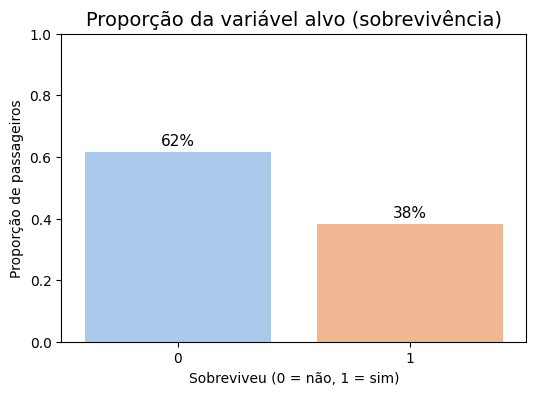

In [20]:
# Calcula proporções
prop = df["survived"].value_counts(normalize=True).reset_index()
prop.columns = ["Sobreviveu", "Proporção"]

plt.figure(figsize=(6,4))
sns.barplot(
    data=prop,
    x="Sobreviveu",
    y="Proporção",
    hue="Sobreviveu",
    legend=False,
    palette="pastel"
)

plt.title("Proporção da variável alvo (sobrevivência)", fontsize=14)
plt.xlabel("Sobreviveu (0 = não, 1 = sim)")
plt.ylabel("Proporção de passageiros")
plt.ylim(0,1)

# Rótulos percentuais acima das barras
for i, row in prop.iterrows():
    plt.text(i, row["Proporção"]+0.02, f"{row['Proporção']:.0%}", ha="center", fontsize=11)

plt.show()

#### Separar variáveis numéricas e categóricas

O dataset Titanic contém variáveis de diferentes tipos, que precisam ser tratadas de formas distintas:

- **Numéricas**: valores contínuos ou discretos que podem ser padronizados.  
  Exemplos: `age`, `sibsp`, `parch`, `fare`.

- **Categóricas**: representam categorias ou grupos, que precisam ser codificados.  
  Exemplos: `pclass`, `sex`, `embarked`, `alone`.

Para simplificação, vamos **descartar variáveis redundantes** ou com muitos valores ausentes neste primeiro modelo (`deck`, `who`, `adult_male`, `embark_town`, `class`, `alive`).


In [21]:
# Variáveis numéricas
num_features = ["age", "sibsp", "parch", "fare"]

# Variáveis categóricas
cat_features = ["pclass", "sex", "embarked", "alone"]

print("Variáveis numéricas:", num_features)
print("Variáveis categóricas:", cat_features)

# Criar novo DataFrame apenas com as variáveis escolhidas
df_model = df[num_features + cat_features].copy()

# Exibe amostra
df_model.head()

Variáveis numéricas: ['age', 'sibsp', 'parch', 'fare']
Variáveis categóricas: ['pclass', 'sex', 'embarked', 'alone']


,age,sibsp,parch,fare,pclass,sex,embarked,alone
0,22.0,1,0,7.2500,3,male,S,False
1,38.0,1,0,71.2833,1,female,C,False
2,26.0,0,0,7.9250,3,female,S,True
3,35.0,1,0,53.1000,1,female,S,False
4,35.0,0,0,8.0500,3,male,S,True


#### Divisão em treino e teste

Para avaliar o modelo de forma justa, separamos os dados em **treino** e **teste**.  
- Usaremos `train_test_split` com **estratificação por `survived`** para manter a proporção de classes nos dois conjuntos.  
- Definimos um `random_state` para reprodutibilidade.  
- Mantemos o `df_model` apenas com as **features** e usamos `y = df["survived"]` como **target**.

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
# X = features selecionadas; y = alvo (survived)
X = df_model.copy()
y = df["survived"].astype(int)

# Split estratificado (ex.: 75% treino, 25% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Checagem rápida dos tamanhos e balanceamento
# Exibir resultados de forma mais clara
print("=== Divisão dos Dados ===")
print(f"Tamanho do treino: {X_train.shape[0]} amostras, {X_train.shape[1]} variáveis")
print(f"Tamanho do teste : {X_test.shape[0]} amostras, {X_test.shape[1]} variáveis\n")

print("=== Proporção de classes no treino ===")
for cls, prop in y_train.value_counts(normalize=True).round(3).items():
    print(f"Classe {cls}: {prop:.1%}")

print("\n=== Proporção de classes no teste ===")
for cls, prop in y_test.value_counts(normalize=True).round(3).items():
    print(f"Classe {cls}: {prop:.1%}")

=== Divisão dos Dados ===
Tamanho do treino: 668 amostras, 8 variáveis
Tamanho do teste : 223 amostras, 8 variáveis

=== Proporção de classes no treino ===
Classe 0: 61.7%
Classe 1: 38.3%

=== Proporção de classes no teste ===
Classe 0: 61.4%
Classe 1: 38.6%


In [24]:
X_train.head()

,age,sibsp,parch,fare,pclass,sex,embarked,alone
486,35.0,1,0,90.000,1,female,S,False
238,19.0,0,0,10.500,2,male,S,True
722,34.0,0,0,13.000,2,male,S,True
184,4.0,0,2,22.025,3,female,S,False
56,21.0,0,0,10.500,2,female,S,True


### Treinamento do Modelo com Pipeline

Para treinar nosso classificador, vamos utilizar a **Regressão Logística**.  
Antes, precisamos garantir que os dados estejam no formato adequado para o modelo:

1. **Padronização (StandardScaler)**  
   - Aplica-se às variáveis numéricas (`age`, `sibsp`, `parch`, `fare`).  
   - Coloca todas na mesma escala (média = 0, desvio padrão = 1).  
   - Isso evita que variáveis com valores grandes (ex.: `fare`) dominem o modelo.

2. **Codificação One-Hot (OneHotEncoder)**  
   - Aplica-se às variáveis categóricas (`pclass`, `sex`, `embarked`, `alone`).  
   - Transforma cada categoria em colunas binárias (0 ou 1).  
   - Exemplo: `sex` vira duas colunas (`sex_female`, `sex_male`).

3. **Pipeline e ColumnTransformer**  
   - Usamos o **ColumnTransformer** para aplicar pré-processamentos diferentes em variáveis numéricas e categóricas.  
   - Em seguida, integramos tudo em um **Pipeline** junto com a Regressão Logística.  
   - Isso garante que:  
     - O pré-processamento seja feito **apenas com os dados de treino**.  
     - O mesmo processamento seja aplicado automaticamente aos dados de teste.  
     - Evitamos *data leakage* e mantemos o código mais limpo.


In [25]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

In [26]:
# Pré-processamento numérico: imputação de medianas + padronização
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [27]:
# Pré-processamento categórico: imputação do mais frequente + OneHot
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [28]:
# ColumnTransformer une os dois
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

In [29]:
# Modelo: Regressão Logística
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Pipeline completo: pré-processamento + modelo
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", logreg)
])

In [30]:
# Treinamento
clf.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


### Avaliação do Modelo

Depois do treinamento, avaliamos o desempenho do classificador nos **dados de teste**.  
Nesta primeira avaliação, usamos o **limiar padrão de 0.5** para decidir se o passageiro sobreviveu (1) ou não (0).

Métricas principais:

- **Matriz de confusão**: mostra acertos e erros do modelo (Verdadeiros Positivos, Verdadeiros Negativos, Falsos Positivos, Falsos Negativos).
- **Acurácia**: proporção total de acertos.
- **Precisão (Precision)**: entre os que o modelo disse que sobreviveram, quantos de fato sobreviveram.
- **Recall (Sensibilidade)**: entre os que realmente sobreviveram, quantos o modelo conseguiu identificar.
- **F1-Score**: equilíbrio entre precisão e recall, útil em problemas com desbalanceamento.

In [31]:

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Previsões no conjunto de teste
y_pred = clf.predict(X_test)


In [33]:
X_test.head()

,age,sibsp,parch,fare,pclass,sex,embarked,alone
157,30.0,0,0,8.0500,3,male,S,True
501,21.0,0,0,7.7500,3,female,Q,True
352,15.0,1,1,7.2292,3,male,C,False
82,NaN,0,0,7.7875,3,female,Q,True
683,14.0,5,2,46.9000,3,male,S,False


In [41]:
print(y_test[:10])

157    0
501    0
352    0
82     1
683    0
84     1
779    1
515    0
728    0
734    0
Name: survived, dtype: int64


In [32]:
y_pred

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0])

In [42]:
# Métricas
acc = accuracy_score(y_test, y_pred)
print("Acurácia:", round(acc, 3))

print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred, digits=3))

Acurácia: 0.785

Relatório de classificação:

              precision    recall  f1-score   support

           0      0.816     0.839     0.827       137
           1      0.732     0.698     0.714        86

    accuracy                          0.785       223
   macro avg      0.774     0.769     0.771       223
weighted avg      0.783     0.785     0.784       223



### Avaliação inicial do modelo

O modelo de Regressão Logística apresentou os seguintes resultados no conjunto de teste:

- **Acurácia:** 0.785 (≈ 78,5% de acertos no total das previsões).

#### Relatório de classificação

| Classe | Precisão (Precision) | Recall (Sensibilidade) | F1-Score | 
|--------|----------------------|-------------------------|----------|
| 0 (Não sobreviveu) | 0.816 | 0.839 | 0.827 |
| 1 (Sobreviveu)     | 0.732 | 0.698 | 0.714 |

- **Classe 0 (não sobreviveu):**
  - **Precisão 0.816** → Quando o modelo prevê que alguém não sobreviveu, acerta em 81,6% dos casos.
  - **Recall 0.839** → Entre os que realmente não sobreviveram, o modelo identificou corretamente 83,9%.
  - **F1 = 0.827** → Equilíbrio entre precisão e recall para essa classe.

- **Classe 1 (sobreviveu):**
  - **Precisão 0.732** → Quando o modelo prevê sobrevivência, acerta em 73,2% dos casos.
  - **Recall 0.698** → Entre os que realmente sobreviveram, o modelo identificou corretamente 69,8%.
  - **F1 = 0.714** → Equilíbrio entre precisão e recall, mas menor que na classe 0.

#### Médias
- **Macro avg:** média simples entre as classes → mostra desempenho equilibrado, sem levar em conta o tamanho de cada classe.  
- **Weighted avg:** média ponderada pelo número de exemplos em cada classe → mais próxima da acurácia, já que a classe 0 é mais frequente.

---

### ✅ Conclusão
- O modelo funciona bem para a classe majoritária (não sobreviveu).  
- Para a classe minoritária (sobreviveu), há perda de recall → parte dos sobreviventes não foi identificada corretamente.  
- Isso mostra a influência do **desbalanceamento das classes** (mais pessoas não sobreviveram do que sobreviveram).  
- Próximo passo: avaliar ajustes de **limiar** ou técnicas para lidar melhor com esse desbalanceamento.


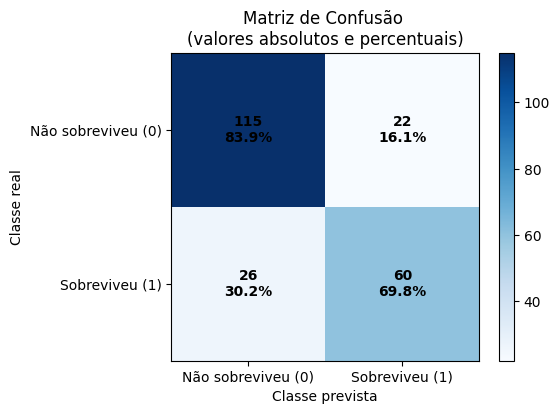

In [43]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]  # percentuais por linha
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]  # percentuais por linha

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap="Blues")

# Títulos e eixos
ax.set_title("Matriz de Confusão \n(valores absolutos e percentuais)")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["Não sobreviveu (0)", "Sobreviveu (1)"])
ax.set_yticklabels(["Não sobreviveu (0)", "Sobreviveu (1)"])

# Adiciona valores absolutos + percentuais
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i,
                f"{cm[i,j]}\n{cm_percent[i,j]:.1%}",
                ha="center", va="center",
                color="black", fontsize=10, fontweight="bold")

# Barra de cores
fig.colorbar(im, ax=ax)
plt.show()

### Interpretação dos resultados

- **Coeficientes do modelo**  
  Analise os coeficientes da Regressão Logística para entender a influência de cada variável.  
  - Valores positivos → aumentam a probabilidade de sobrevivência.  
  - Valores negativos → reduzem a probabilidade de sobrevivência.

In [44]:
import numpy as np
import pandas as pd

In [45]:
# === 1) Recuperar nomes das features após o pré-processamento ===
# Numéricas entram como estão:
num_names = num_features  # ["age", "sibsp", "parch", "fare"]

# Categóricas vêm do OneHotEncoder:
ohe = clf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(cat_features)  # ex.: ['pclass_1', 'pclass_2', ..., 'sex_female', 'sex_male', ...]

# Todas as features, na ordem usada pelo modelo:
feature_names = np.concatenate([num_names, cat_names])

In [46]:
# === 2) Coeficientes do modelo ===
coefs = clf.named_steps["classifier"].coef_.ravel()  # vetor 1D

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
})

In [47]:
# Ordenações úteis:
print("Top 15 por valor (positivos no topo):")
display(coef_df.sort_values("coef", ascending=False).head(15))

print("\nTop 15 por valor (negativos no topo):")
display(coef_df.sort_values("coef", ascending=True).head(15))

print("\nTop 15 por magnitude |coef|:")
display(coef_df.sort_values("abs_coef", ascending=False).head(15))

Top 15 por valor (positivos no topo):


,feature,coef,abs_coef
7,sex_female,1.270016,1.270016
4,pclass_1,1.029256,1.029256
10,embarked_Q,0.323003,0.323003
12,alone_False,0.285122,0.285122
3,fare,0.133134,0.133134
5,pclass_2,0.012332,0.012332
9,embarked_C,-0.012362,0.012362
2,parch,-0.136319,0.136319
13,alone_True,-0.285474,0.285474
11,embarked_S,-0.310993,0.310993



Top 15 por valor (negativos no topo):


,feature,coef,abs_coef
8,sex_male,-1.270368,1.270368
6,pclass_3,-1.041940,1.041940
0,age,-0.505971,0.505971
1,sibsp,-0.410827,0.410827
11,embarked_S,-0.310993,0.310993
13,alone_True,-0.285474,0.285474
2,parch,-0.136319,0.136319
9,embarked_C,-0.012362,0.012362
5,pclass_2,0.012332,0.012332
3,fare,0.133134,0.133134



Top 15 por magnitude |coef|:


,feature,coef,abs_coef
8,sex_male,-1.270368,1.270368
7,sex_female,1.270016,1.270016
6,pclass_3,-1.041940,1.041940
4,pclass_1,1.029256,1.029256
0,age,-0.505971,0.505971
1,sibsp,-0.410827,0.410827
10,embarked_Q,0.323003,0.323003
11,embarked_S,-0.310993,0.310993
13,alone_True,-0.285474,0.285474
12,alone_False,0.285122,0.285122


### Interpretação dos coeficientes do modelo

A análise dos coeficientes da Regressão Logística mostra a influência de cada variável na probabilidade de sobrevivência:

- **Sexo**
  - `sex_male (–1.27)` → ser **homem** reduz fortemente a chance de sobreviver.
  - `sex_female (+1.27)` → ser **mulher** aumenta fortemente a chance de sobreviver.
  - Esse foi o fator mais importante no modelo.

- **Classe do bilhete**
  - `pclass_3 (–1.04)` → estar na **3ª classe** reduz significativamente a probabilidade.
  - `pclass_1 (+1.03)` → estar na **1ª classe** aumenta a probabilidade.
  - Mostra a influência direta das condições socioeconômicas.

- **Idade**
  - `age (–0.51)` → idade mais alta está associada a menor chance de sobrevivência.
  - Indica que **crianças foram priorizadas** nos resgates.

- **Família a bordo**
  - `sibsp (–0.41)` → mais irmãos/cônjuges reduzem a chance de sobrevivência.
  - Pode indicar dificuldade em salvar famílias grandes juntas.

- **Porto de embarque**
  - `embarked_Q (+0.32)` → embarcar em **Queenstown (Q)** aumentou um pouco a chance.
  - `embarked_S (–0.31)` → embarcar em **Southampton (S)** reduziu a chance.
  - Diferença pode refletir perfis distintos de passageiros por porto.

- **Sozinho ou acompanhado**
  - `alone_True (–0.28)` → estar sozinho reduziu a probabilidade.
  - `alone_False (+0.29)` → estar acompanhado aumentou a probabilidade.

- **Tarifa**
  - `fare (+0.13)` → tarifas mais altas aumentaram ligeiramente a chance de sobrevivência.
  - Coerente com a associação entre tarifas altas e 1ª classe.

---

### ✅ Conclusão
Os coeficientes confirmam os padrões históricos do desastre do Titanic:
- **Mulheres e passageiros da 1ª classe tiveram maiores chances de sobrevivência.**
- **Homens, passageiros da 3ª classe e pessoas mais velhas foram os mais prejudicados.**
- Outras variáveis como tarifa, porto de embarque e estar sozinho tiveram impacto menor, mas consistente.